# 03 — UV-Excess Selection

Stage 3 of 5. Applies the color-color + E(B-V) UV-excess selection criterion to the combined
catalog from [02 — Merge & Dedupe](02_merge_and_dedupe.ipynb), then visualizes the selection.

**Pipeline:** [01 — Crossmatch](01_crossmatch.ipynb) → [02 — Merge & Dedupe](02_merge_and_dedupe.ipynb)
→ **03 — UV-Excess Selection** → [04 — Visual Review & Final Sample](04_visual_review_final_sample.ipynb)
→ [05 — Control Sample](05_control_sample.ipynb)

**Selection criterion:** FUV/NUV or NUV/G "upturn" in flux-ratio space
(`(NUV/G > 1 & G/R < 1) | (FUV/NUV > 1 & NUV/G < 1)`), AND E(B-V) > `uv_excess.ebv_min` from
config — applied to DESI rows only; W2M's own E(B-V) column runs much lower by design
(median ~0.03), so it's exempted from that half of the cut, matching every current script.

**Inputs:** `data/matched/DESI_COMBINED_matched.csv`, `data/matched/W2M_COMBINED_matched.csv`,
`data/matched/FINAL_COMBINED_QSOs_W2M.csv`

**Output:** `data/matched/uv_excess_candidates_w2m.csv` (34 candidates) — canonical candidate list;
[04 — Visual Review & Final Sample](04_visual_review_final_sample.ipynb) does not recompute this.

**Script references:** `scripts/matching/candidates_to_csv_w2m.py`, `scripts/colorcolor/colorcolor_w2m.py`,
`ebv_uv_excess_histogram.py`, `ebv_uv_excess_fraction_barchart.py`, `gmag_histogram.py`

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.table import Table, vstack
from synphot import units as su

BASE_DIR = Path.cwd().parent
with open(BASE_DIR / "config" / "qso_params.yaml") as f:
    PARAMS = yaml.safe_load(f)

DATA_MATCHED = BASE_DIR / "data" / "matched"
FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WAVELENGTHS = PARAMS["band_wavelengths_AA"]
FLAM_MAX_GALEX_PS1 = PARAMS["flux_outlier_thresholds_flam"]["galex_panstarrs"] * su.FLAM
EBV_MIN = PARAMS["uv_excess"]["ebv_min"]
TARGET_SAMPLE_MAX = PARAMS["uv_excess"]["target_sample_max"]

DESI_OUT = DATA_MATCHED / "DESI_COMBINED_matched.csv"
W2M_OUT = DATA_MATCHED / "W2M_COMBINED_matched.csv"
CANDIDATES_OUT = DATA_MATCHED / "uv_excess_candidates_w2m.csv"


def mag_arr(col):
    if hasattr(col, 'filled'):
        return np.array(col.filled(np.nan), dtype=float)
    arr = np.array(col, dtype=str)
    arr[arr == '--'] = 'nan'
    return arr.astype(float)


def to_flam(tbl, col, band):
    lam = WAVELENGTHS[band] * u.AA
    flam = (mag_arr(tbl[col]) * u.ABmag).to(su.FLAM, u.spectral_density(lam))
    flam[flam > FLAM_MAX_GALEX_PS1] = np.nan
    return flam

## Candidate selection

Source: `scripts/matching/candidates_to_csv_w2m.py`.

In [2]:
def uv_excess_mask(tbl, gmag_col, rmag_col, require_ebv=True, ebv_col='EBV'):
    flam_fuv = to_flam(tbl, 'FUVmag', 'FUV')
    flam_nuv = to_flam(tbl, 'NUVmag', 'NUV')
    flam_g = to_flam(tbl, gmag_col, 'g')
    flam_r = to_flam(tbl, rmag_col, 'r')

    f_fn = flam_fuv / flam_nuv
    f_ng = flam_nuv / flam_g
    f_gr = flam_g / flam_r

    # NUV/g > 1 & g/r < 1: NUV excess over optical continuum (NUV upturn)
    # FUV/NUV > 1 & NUV/g < 1: FUV upturn with suppressed NUV (patchy geometry signature)
    flux_criterion = (
        ((f_ng > 1) & (f_gr < 1)) |
        ((f_fn > 1) & (f_ng < 1))
    )

    if require_ebv:
        ebv = mag_arr(tbl[ebv_col])
        return flux_criterion & (ebv > EBV_MIN)
    return flux_criterion


desi = Table.read(DESI_OUT, format='csv')
desi_mask = uv_excess_mask(desi, gmag_col='gmag', rmag_col='rmag', require_ebv=True)
desi_cands = desi[desi_mask]

# W2M sample is pre-restricted to spCl == 'redQSO' at crossmatch time; its EBV
# runs much lower than DESI's (median ~0.03), so the E(B-V) cut is not applied.
w2m = Table.read(W2M_OUT, format='csv')
w2m_mask = uv_excess_mask(w2m, gmag_col='gmag_2', rmag_col='rmag_2', require_ebv=False)
w2m_cands = w2m[w2m_mask]

candidates = vstack([desi_cands, w2m_cands], join_type='outer')
candidates.write(CANDIDATES_OUT, format='csv', overwrite=True)
print(f"  -> {len(desi_cands)} DESI + {len(w2m_cands)} W2M = {len(candidates)} candidates written to {CANDIDATES_OUT}")
if len(candidates) > TARGET_SAMPLE_MAX:
    print(f"  WARNING: candidate sample ({len(candidates)}) exceeds target max ({TARGET_SAMPLE_MAX}) -- investigate.")

  -> 18 DESI + 16 W2M = 34 candidates written to /Users/alexgs/Documents/UV_Leakage_Geometry/UV_Leakage_Geometry/data/matched/uv_excess_candidates_w2m.csv


## Color-color: full combined sample

Source: `scripts/colorcolor/colorcolor_w2m.py`. FUV/NUV vs NUV/G ("upturn branch") and
NUV/G vs G/R, over the full `FINAL_COMBINED_QSOs_W2M.csv` sample, colored by candidate status.
Reference lines at ratio = 1 mark the UV-excess boundary in each panel.

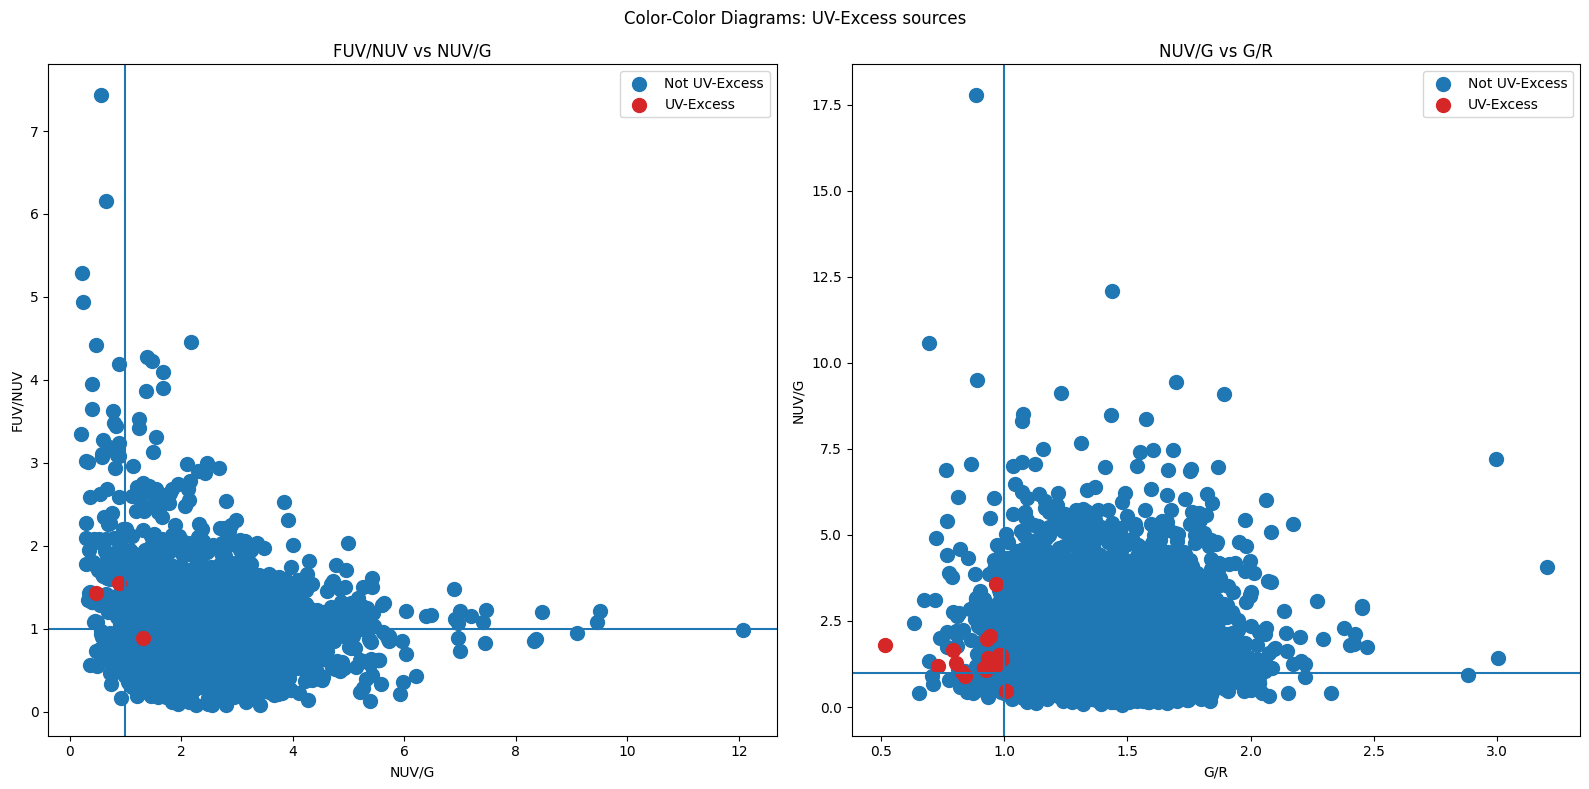

In [3]:
full_table = Table.read(DATA_MATCHED / "FINAL_COMBINED_QSOs_W2M.csv", format='csv')

FUVmags = mag_arr(full_table['FUVmag'])
NUVmags = mag_arr(full_table['NUVmag'])
gmags = mag_arr(full_table['gmag'])
rmags = mag_arr(full_table['rmag'])
imags = mag_arr(full_table['imag'])

flam_fuv = to_flam(full_table, 'FUVmag', 'FUV')
flam_nuv = to_flam(full_table, 'NUVmag', 'NUV')
flam_g = to_flam(full_table, 'gmag', 'g')
flam_r = to_flam(full_table, 'rmag', 'r')
flam_i = to_flam(full_table, 'imag', 'i')

fuvnuv = flam_fuv / flam_nuv
nuvg = flam_nuv / flam_g
gr = flam_g / flam_r
ri = flam_r / flam_i

# mask out rows where a mag used in that specific color is 0
# (0 indicates a missing/bad measurement, not a real magnitude)
fuvnuv[(FUVmags == 0) | (NUVmags == 0)] = np.nan
nuvg[(NUVmags == 0) | (gmags == 0)] = np.nan
gr[(gmags == 0) | (rmags == 0)] = np.nan
ri[(rmags == 0) | (imags == 0)] = np.nan

# candidate flag by TARGETID (DESI rows) or designation (W2M rows without a DESI TARGETID)
sentinel_ids = {'0', 'nan', '--'}
candidate_ids = (
    (set(np.array(candidates['TARGETID'], dtype=str)) |
     set(np.array(candidates['designation'], dtype=str)))
    - sentinel_ids
)
row_ids = np.array(full_table['TARGETID'], dtype=str)
row_designations = np.array(full_table['designation'], dtype=str)
is_candidate = np.isin(row_ids, list(candidate_ids)) | np.isin(row_designations, list(candidate_ids))
not_candidate = ~is_candidate

fig, (ax_blue, ax_red) = plt.subplots(1, 2, figsize=(16, 8))

ax_blue.scatter(nuvg[not_candidate], fuvnuv[not_candidate], c='tab:blue', s=100, zorder=2, label='Not UV-Excess')
ax_blue.scatter(nuvg[is_candidate], fuvnuv[is_candidate], c='tab:red', s=100, zorder=2, label='UV-Excess')
ax_red.scatter(gr[not_candidate], nuvg[not_candidate], c='tab:blue', s=100, zorder=2, label='Not UV-Excess')
ax_red.scatter(gr[is_candidate], nuvg[is_candidate], c='tab:red', s=100, zorder=2, label='UV-Excess')

ax_blue.set_xlabel('NUV/G')
ax_blue.set_ylabel('FUV/NUV')
ax_blue.set_title('FUV/NUV vs NUV/G')
ax_blue.axhline(y=1)
ax_blue.axvline(x=1)
ax_blue.legend(loc='best')

ax_red.set_xlabel('G/R')
ax_red.set_ylabel('NUV/G')
ax_red.set_title('NUV/G vs G/R')
ax_red.axhline(y=1)
ax_red.axvline(x=1)
ax_red.legend(loc='best')

fig.suptitle('Color-Color Diagrams: UV-Excess sources')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "colorcolor_selection.png", dpi=150)
plt.show()

## E(B-V) distribution: UV-excess vs. non-UV-excess

Source: `scripts/colorcolor/ebv_uv_excess_histogram.py`. DESI rows use `EBV`/`gmag`/`rmag`; W2M
rows (`src == 'w2m'`) use their own lowercase `ebv`/`gmag_2`/`rmag_2` and skip the E(B-V) cut.

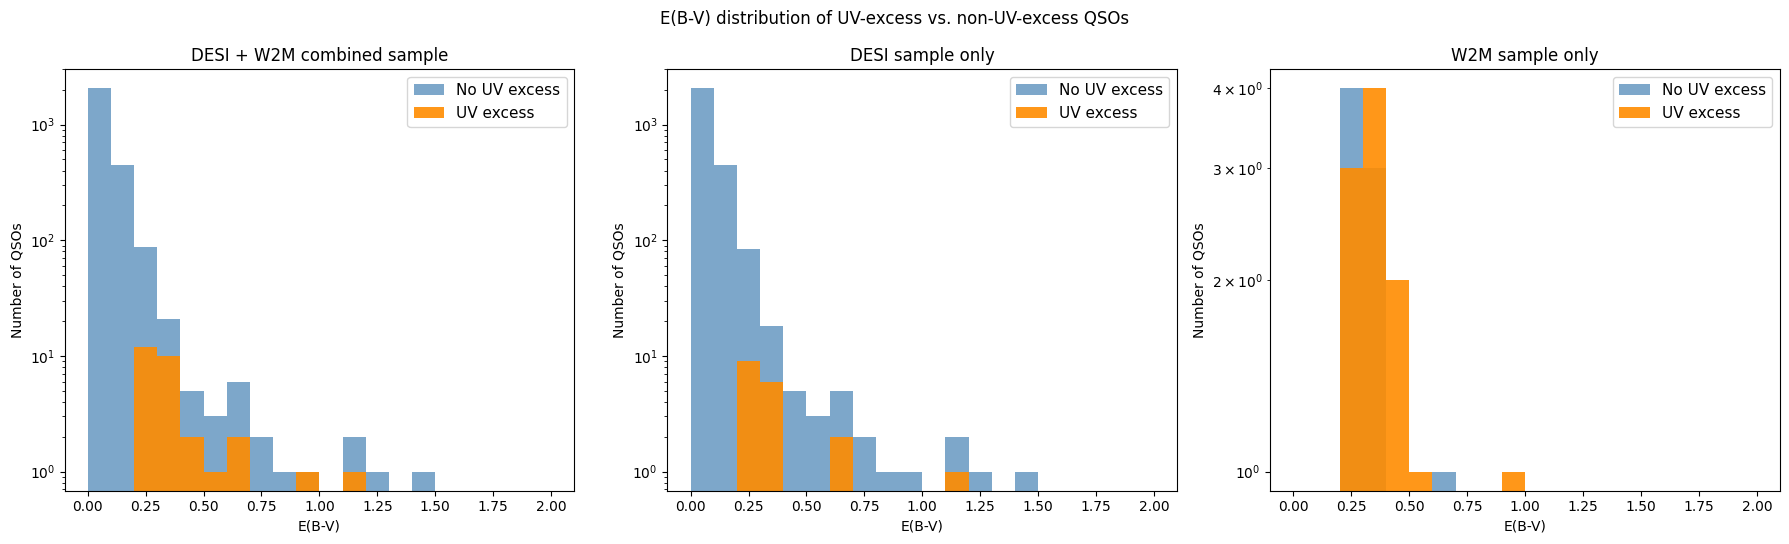

In [4]:
src = np.array(full_table['src'], dtype=str)
is_desi = src != 'w2m'
is_w2m = ~is_desi

uv_flag = np.zeros(len(full_table), dtype=bool)
if np.any(is_desi):
    uv_flag[is_desi] = uv_excess_mask(full_table[is_desi], gmag_col='gmag', rmag_col='rmag', require_ebv=True)
if np.any(is_w2m):
    uv_flag[is_w2m] = uv_excess_mask(full_table[is_w2m], gmag_col='gmag_2', rmag_col='rmag_2', require_ebv=False)

ebv_desi_all = mag_arr(full_table['EBV'])
ebv_w2m_all = mag_arr(full_table['ebv'])

ebv_desi = ebv_desi_all[is_desi]
uv_flag_desi = uv_flag[is_desi]
ebv_w2m = ebv_w2m_all[is_w2m]
uv_flag_w2m = uv_flag[is_w2m]
ebv_combined = np.concatenate([ebv_desi, ebv_w2m])
uv_flag_combined = np.concatenate([uv_flag_desi, uv_flag_w2m])


def plot_ebv_histogram(ax, ebv, flag, title):
    bin_edges = np.arange(0, 2 + 0.1, 0.1)
    ax.hist(ebv[~flag], bins=bin_edges, histtype='stepfilled', color='steelblue', alpha=0.7,
            label='No UV excess')
    ax.hist(ebv[flag], bins=bin_edges, histtype='stepfilled', color='darkorange', alpha=0.9,
            label='UV excess')
    ax.set_title(title)
    ax.set_xlabel('E(B-V)')
    ax.set_ylabel('Number of QSOs')
    ax.legend(fontsize=11)
    ax.set_yscale('log')


fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plot_ebv_histogram(axes[0], ebv_combined, uv_flag_combined, 'DESI + W2M combined sample')
plot_ebv_histogram(axes[1], ebv_desi, uv_flag_desi, 'DESI sample only')
plot_ebv_histogram(axes[2], ebv_w2m, uv_flag_w2m, 'W2M sample only')
fig.suptitle('E(B-V) distribution of UV-excess vs. non-UV-excess QSOs')
fig.tight_layout()
plt.savefig(FIGURES_DIR / "ebv_histogram.png", dpi=150)
plt.show()

## UV-excess fraction per E(B-V) bin

Source: `scripts/colorcolor/ebv_uv_excess_fraction_barchart.py`. Reuses the `ebv_combined`/
`uv_flag_combined` arrays computed above.

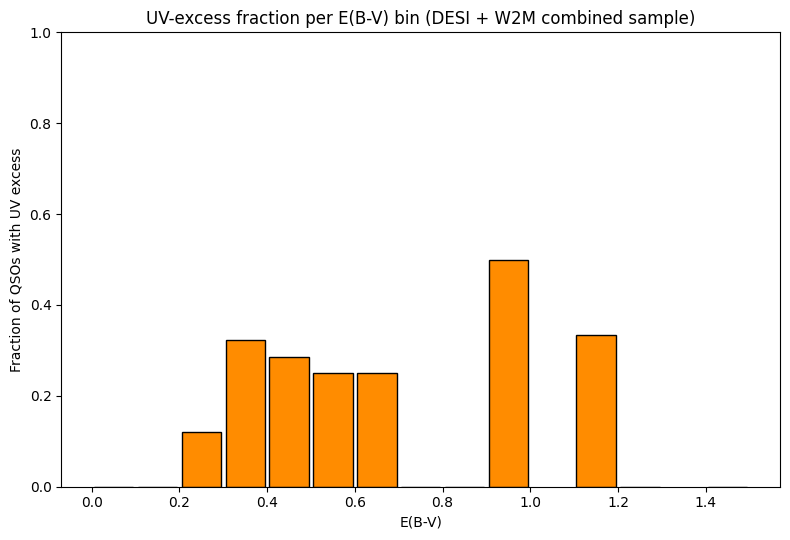

In [5]:
bin_edges = np.arange(0, 2 + 0.1, 0.1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

total_counts, _ = np.histogram(ebv_combined, bins=bin_edges)
excess_counts, _ = np.histogram(ebv_combined[uv_flag_combined], bins=bin_edges)

with np.errstate(invalid='ignore', divide='ignore'):
    fraction = np.where(total_counts > 0, excess_counts / total_counts, np.nan)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(bin_centers, fraction, width=0.09, color='darkorange', edgecolor='black')
ax.set_xlabel('E(B-V)')
ax.set_ylabel('Fraction of QSOs with UV excess')
ax.set_title('UV-excess fraction per E(B-V) bin (DESI + W2M combined sample)')
ax.set_ylim(0, 1)
fig.tight_layout()
plt.savefig(FIGURES_DIR / "uv_excess_fraction.png", dpi=150)
plt.show()

## Apparent g-mag distribution: all QSOs vs. UV-excess candidates

Source: `scripts/colorcolor/gmag_histogram.py`. Uses `pandas`/`Int64` for `TARGETID` (not
`astropy.table`) -- 17-digit DESI TARGETIDs lose precision as float64, so this dtype choice
matters and is kept consistent with the source script.

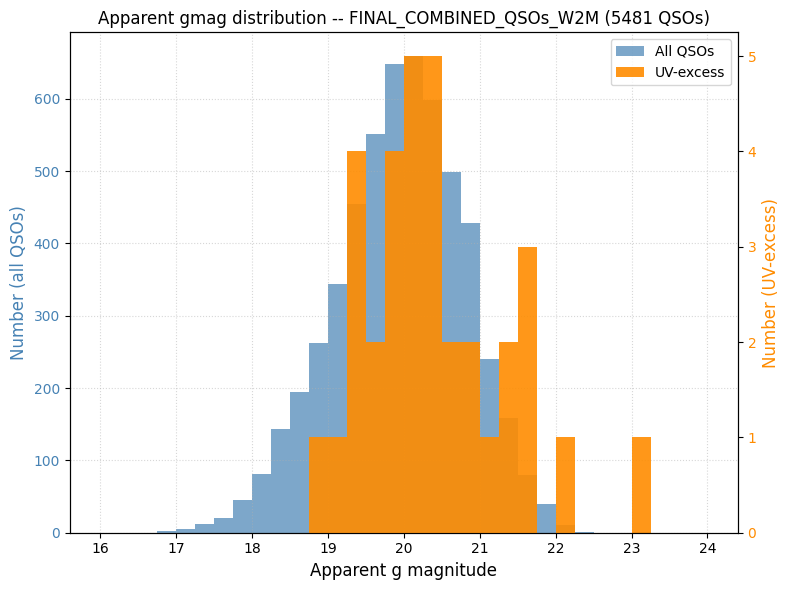

In [6]:
df = pd.read_csv(DATA_MATCHED / "FINAL_COMBINED_QSOs_W2M.csv", dtype={"TARGETID": "Int64"})
cand_df = pd.read_csv(CANDIDATES_OUT, dtype={"TARGETID": "Int64"})

matched_by_id = df["TARGETID"].isin(cand_df["TARGETID"].dropna()) & df["TARGETID"].notna()
matched_by_designation = (
    df["designation"].isin(cand_df.loc[cand_df["TARGETID"].isna(), "designation"].dropna())
    & df["designation"].notna()
)
is_candidate_df = matched_by_id | matched_by_designation

gmag_df = df["gmag"].where(df["gmag"].notna(), df["gmag_2"])
mask = gmag_df.notna()
app_g = gmag_df[mask]

bin_edges = np.arange(np.floor(app_g.min()), np.ceil(app_g.max()) + 0.25, 0.25)

fig, ax = plt.subplots(figsize=(8, 6))
ax_cand = ax.twinx()

ax.hist(app_g, bins=bin_edges, histtype="stepfilled", color="steelblue", alpha=0.7, label="All QSOs")
ax_cand.hist(app_g[is_candidate_df[mask]], bins=bin_edges, histtype="stepfilled",
             color="darkorange", alpha=0.9, label="UV-excess")

ax.set_xlabel("Apparent g magnitude", fontsize=12)
ax.set_ylabel("Number (all QSOs)", fontsize=12, color="steelblue")
ax.tick_params(axis="y", labelcolor="steelblue")
ax_cand.set_ylabel("Number (UV-excess)", fontsize=12, color="darkorange")
ax_cand.tick_params(axis="y", labelcolor="darkorange")
ax_cand.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax.set_title(f"Apparent gmag distribution -- FINAL_COMBINED_QSOs_W2M ({mask.sum()} QSOs)")
ax.grid(linestyle=":", alpha=0.5)
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_cand.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "gmag_histogram.png", dpi=150)
plt.show()